In [21]:
import pandas as pd
import re
import matplotlib.pyplot as plt
from textblob import TextBlob


In [22]:

print("Columns:", df.columns.tolist())
print(df.head())


Columns: ['Comment', 'Cleaned_Comment', 'Sentiment', 'Viewer_Interest']
                                             Comment  \
0   My money was deducted but the transaction failed   
1       I was charged twice for the same transaction   
2  The ATM did not dispense cash but money was de...   
3           My online banking account is not working   
4  I cannot log in to the mobile banking application   

                                     Cleaned_Comment Sentiment  \
0   my money was deducted but the transaction failed  Negative   
1       i was charged twice for the same transaction   Neutral   
2  the atm did not dispense cash but money was de...   Neutral   
3           my online banking account is not working   Neutral   
4  i cannot log in to the mobile banking application   Neutral   

    Viewer_Interest  
0  General Feedback  
1  General Feedback  
2  General Feedback  
3  General Feedback  
4  General Feedback  


In [23]:

df = df.rename(columns={"Complaint": "Comment"})

print("\nNew Columns:")
print(df.columns.tolist())



New Columns:
['Comment', 'Cleaned_Comment', 'Sentiment', 'Viewer_Interest']


In [24]:
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df["Cleaned_Comment"] = df["Comment"].apply(preprocess)



In [25]:

def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"


df["Sentiment"] = df["Cleaned_Comment"].apply(get_sentiment)



In [26]:
def find_interest(text):

    if "python" in text:
        return "Python"

    elif "machine learning" in text:
        return "Machine Learning"

    elif "data science" in text:
        return "Data Science"

    elif "tutorial" in text:
        return "Tutorial"

    elif "audio" in text or "sound" in text:
        return "Audio Quality"

    elif "editing" in text:
        return "Editing"

    else:
        return "General Feedback"


df["Viewer_Interest"] = df["Cleaned_Comment"].apply(
    find_interest
)


In [27]:

print("\nANALYSIS RESULTS:")
print(
    df[
        [
            "Comment",
            "Sentiment",
            "Viewer_Interest"
        ]
    ].head(10)
)




ANALYSIS RESULTS:
                                             Comment Sentiment  \
0   My money was deducted but the transaction failed  Negative   
1       I was charged twice for the same transaction   Neutral   
2  The ATM did not dispense cash but money was de...   Neutral   
3           My online banking account is not working   Neutral   
4  I cannot log in to the mobile banking application   Neutral   
5                The bank application keeps crashing   Neutral   
6  My loan application has been rejected without ...   Neutral   
7                 The loan interest rate is too high  Positive   
8      I am unable to pay my loan installment online  Negative   
9                My account was blocked unexpectedly  Positive   

    Viewer_Interest  
0  General Feedback  
1  General Feedback  
2  General Feedback  
3  General Feedback  
4  General Feedback  
5  General Feedback  
6  General Feedback  
7  General Feedback  
8  General Feedback  
9  General Feedback  


In [28]:
sentiment_count = df["Sentiment"].value_counts()

print("\nAUDIENCE REACTIONS:")
print(sentiment_count)



AUDIENCE REACTIONS:
Sentiment
Neutral     21
Negative    11
Positive     3
Name: count, dtype: int64


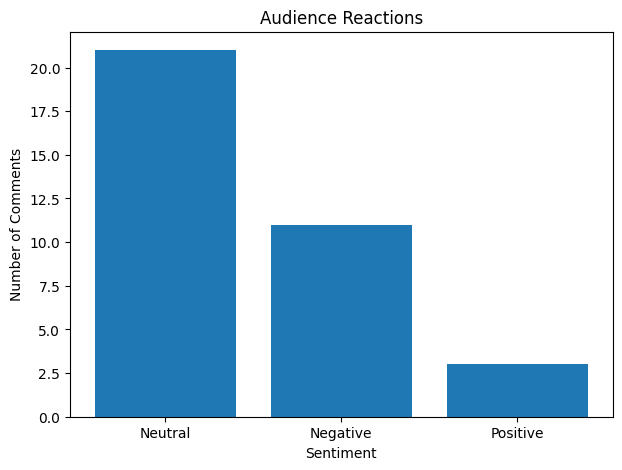

In [29]:
plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_count.index,
    sentiment_count.values
)

plt.title("Audience Reactions")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")

plt.show()


In [30]:

df.to_csv(
    "youtube_comment_analysis.csv",
    index=False
)

print("\nAnalysis Completed Successfully!")


Analysis Completed Successfully!
